<a href="https://colab.research.google.com/github/thatginger12345/CAN-IDS-DISSERTATION/blob/main/DISS_CAN_BUS_IDS_fixed_fuzzy_all_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#initial imports

import pandas as pd
import numpy as np
import time
import os



intial libaries i imported

*   i use pandas to store and manipulate the data
* NumPy is for numerical operations
* time allows me to measure model latency later on
* os lets me check file pats and ensure that datasets exist



In [ ]:
# Checkpoint function to inspect datasets after each major step
def check_df(df, name="DataFrame", rows=5):
    print("=" * 80)
    print(f"CHECKPOINT: {name}")
    print("=" * 80)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst rows:")
    display(df.head(rows))

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

    if "label" in df.columns:
        print("\nLabel distribution:")
        print(df["label"].value_counts(dropna=False))

    if "attack_type" in df.columns:
        print("\nAttack type distribution:")
        print(df["attack_type"].value_counts(dropna=False))

    print("\n")


# Special fuzzy checker
def check_fuzzy_bytes(df, name="Fuzzy dataset", rows=10):
    print("=" * 80)
    print(f"FUZZY BYTE CHECK: {name}")
    print("=" * 80)

    data_cols = [col for col in df.columns if col.startswith("data")]

    print("\nData byte preview:")
    display(df[data_cols].head(rows))

    print("\nUnique values per data byte column:")
    for col in data_cols:
        print(col, df[col].nunique(dropna=False))

    print("\n")

this is a checkpoint function that i can call back to to check my work
had issues as i accidentally cleaned the fuzzy attack to much so i added this to help troubleshoot

In [ ]:
#uploading datasets from my google drive

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/CAN BUS DATASETS/"

NORMAL_PATH = BASE_PATH + "normal_run_data.txt"
DOS_PATH = BASE_PATH + "DoS_dataset (1).csv"
FUZZY_PATH = BASE_PATH + "Fuzzy_dataset.csv"
RPM_PATH = BASE_PATH + "RPM_dataset.csv"
GEAR_PATH = BASE_PATH + "gear_dataset (3).csv"

print("Files found:")
for file in os.listdir(BASE_PATH):
    print(file)

# Safety checks
assert os.path.exists(NORMAL_PATH), "Normal dataset missing!"
assert os.path.exists(DOS_PATH), "DoS dataset missing!"
assert os.path.exists(FUZZY_PATH), "Fuzzy dataset missing!"
assert os.path.exists(RPM_PATH), "RPM dataset missing!"
assert os.path.exists(GEAR_PATH), "Gear dataset missing!"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found:
normal_run_data.txt
Fuzzy_dataset.csv
RPM_dataset.csv
DoS_dataset (1).csv
gear_dataset (3).csv




*   BASE_PATH links to the folder on google drive that contains the files
*   i also added a pathway for each dataset
* the print function allows me to check that all the files exist
* assert statement allows me to ensure the pathways are created, if the assert statement = false there will be an assertion error



In [ ]:
#Parse normal TXT data


def parse_normal_txt(path):
    rows = []

    with open(path, "r", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()

            try:
                timestamp = float(parts[1])
                can_id = parts[3]
                dlc = int(parts[7])
                data = parts[8:8+dlc]

                while len(data) < 8:
                    data.append("00")

                rows.append([timestamp, can_id, dlc] + data[:8])

            except:
                continue

    columns = ["timestamp", "can_id", "dlc"] + [f"data{i}" for i in range(8)]
    df = pd.DataFrame(rows, columns=columns)

    df["label"] = 0
    df["attack_type"] = "normal"

    return df

converting raw data in the .txt into structured data

*   splits each indidual line of data into its indiviual parts
*   Labels each line as normal data - 0
* extracts the relevant fields
* extracts the column headings
* pads lines that arent full so they all have 8 bytes of data




In [ ]:

#Load attack data

def load_attack_csv(path, attack_name):
    rows = []

    with open(path, "r", errors="ignore") as file:
        for line in file:
            parts = line.strip().split(",")

            try:
                timestamp = parts[0]
                can_id = parts[1]
                dlc = int(parts[2])

                # flag is the last value
                flag = parts[-1].strip()

                # ensuring all lines of data have 8 bytes
                data = parts[3:-1]

                while len(data) < 8:
                    data.append("00")

                data = data[:8]

                #relabelling flags to binary numbers
                label = 1 if flag == "T" else 0

                rows.append([timestamp, can_id, dlc] + data + [label, attack_name])

            except:
                continue

    columns = (
        ["timestamp", "can_id", "dlc"]
        + [f"data{i}" for i in range(8)]
        + ["label", "attack_type"]
    )

    return pd.DataFrame(rows, columns=columns)



*   loads attack datasets
*   converts flags to binary numbers

*  removes original flag column
*   ensures the attack data matchs the regular traffic





In [ ]:
#Convert CAN fields to integers from hex strings

def clean_can_dataframe(df):
    df = df.copy()

    df["can_id"] = df["can_id"].astype(str).str.replace("0x", "", regex=False)
    df["can_id"] = df["can_id"].apply(lambda x: int(x, 16))

    for i in range(8):
        df[f"data{i}"] = df[f"data{i}"].astype(str).str.replace("0x", "", regex=False)
        df[f"data{i}"] = df[f"data{i}"].replace(["nan", "None", ""], "00")
        df[f"data{i}"] = df[f"data{i}"].apply(lambda x: int(x, 16))

    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["dlc"] = pd.to_numeric(df["dlc"], errors="coerce")

    df = df.dropna()

    return df



*   ensures each row is full and hexidecimals are converted to integers




In [ ]:

print(os.listdir('/content'))

assert os.path.exists(NORMAL_PATH), "Normal dataset not found!"

['.config', 'drive', 'sample_data']


* verifies the dataset is available


*   Lists files
*  checks the pathways exist
* prevents errors due to missing files



In [ ]:
#Loading datasets using sampling

SAMPLE_NORMAL = 200_000
SAMPLE_ATTACK_FILE = 250_000

normal_df = parse_normal_txt(NORMAL_PATH)
normal_df = normal_df.sample(
    n=min(SAMPLE_NORMAL, len(normal_df)),
    random_state=42
)

dos_df = load_attack_csv(DOS_PATH, "DoS")
dos_df = dos_df.sample(
    n=min(SAMPLE_ATTACK_FILE, len(dos_df)),
    random_state=42
)

fuzzy_df = load_attack_csv(FUZZY_PATH, "Fuzzy")
fuzzy_df = fuzzy_df.sample(
    n=min(SAMPLE_ATTACK_FILE, len(fuzzy_df)),
    random_state=42
)

rpm_df = load_attack_csv(RPM_PATH, "RPM Spoofing")
rpm_df = rpm_df.sample(
    n=min(SAMPLE_ATTACK_FILE, len(rpm_df)),
    random_state=42
)

gear_df = load_attack_csv(GEAR_PATH, "Gear Spoofing")
gear_df = gear_df.sample(
    n=min(SAMPLE_ATTACK_FILE, len(gear_df)),
    random_state=42
)

normal_df = clean_can_dataframe(normal_df)
dos_df = clean_can_dataframe(dos_df)
rpm_df = clean_can_dataframe(rpm_df)
gear_df = clean_can_dataframe(gear_df)

# Fuzzy is deliberately not cleaned here
# This converts fuzzy_df into numeric format so the model can use it. It does NOT run the full clean_can_dataframe() function.

fuzzy_df = fuzzy_df.copy()

# Convert timestamp and DLC to numeric
fuzzy_df["timestamp"] = pd.to_numeric(fuzzy_df["timestamp"], errors="coerce")
fuzzy_df["dlc"] = pd.to_numeric(fuzzy_df["dlc"], errors="coerce")

# Convert CAN ID from hex string to integer
fuzzy_df["can_id"] = fuzzy_df["can_id"].apply(
    lambda x: int(str(x), 16) if isinstance(x, str) else x
)

# Convert data bytes from hex string to integer
data_cols = [f"data{i}" for i in range(8)]

for col in data_cols:
    fuzzy_df[col] = fuzzy_df[col].apply(
        lambda x: int(str(x), 16) if isinstance(x, str) else x
    )

# Drop only rows where conversion failed
fuzzy_df = fuzzy_df.dropna(subset=["timestamp", "can_id", "dlc"] + data_cols)

# Force model columns to numeric
model_numeric_cols = ["timestamp", "can_id", "dlc"] + data_cols
fuzzy_df[model_numeric_cols] = fuzzy_df[model_numeric_cols].astype(float)

check_df(fuzzy_df, "Fuzzy after separate model-only conversion")

print("Loaded dataset sizes:")
print("Normal:", len(normal_df))
print("DoS:", len(dos_df))
print("Fuzzy:", len(fuzzy_df))
print("RPM:", len(rpm_df))
print("Gear:", len(gear_df))

CHECKPOINT: Fuzzy after separate model-only conversion

Shape:
(250000, 13)

Columns:
['timestamp', 'can_id', 'dlc', 'data0', 'data1', 'data2', 'data3', 'data4', 'data5', 'data6', 'data7', 'label', 'attack_type']

First rows:


,timestamp,can_id,dlc,data0,data1,data2,data3,data4,data5,data6,data7,label,attack_type
965508,1.478196e+09,497.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Fuzzy
364018,1.478196e+09,704.0,8.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Fuzzy
3663640,1.478201e+09,880.0,8.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Fuzzy
1906757,1.478197e+09,1088.0,8.0,255.0,0.0,0.0,0.0,255.0,203.0,8.0,0.0,0,Fuzzy
1059026,1.478196e+09,339.0,8.0,0.0,33.0,16.0,255.0,0.0,255.0,0.0,0.0,0,Fuzzy



Data types:
timestamp      float64
can_id         float64
dlc            float64
data0          float64
data1          float64
data2          float64
data3          float64
data4          float64
data5          float64
data6          float64
data7          float64
label            int64
attack_type     object
dtype: object

Missing values:
timestamp      0
can_id         0
dlc            0
data0          0
data1          0
data2          0
data3          0
data4          0
data5          0
data6          0
data7          0
label          0
attack_type    0
dtype: int64

Duplicate rows:
0

Label distribution:
label
0    218000
1     32000
Name: count, dtype: int64

Attack type distribution:
attack_type
Fuzzy    250000
Name: count, dtype: int64


Loaded dataset sizes:
Normal: 200000
DoS: 250000
Fuzzy: 250000
RPM: 250000
Gear: 250000




*   Loads all datasets to memory

*   uses sampling to reduce the size of the datasets, due to colab crashing

*   uses fixed random state for reproducability
*   prints dataset sizes






In [ ]:
#adding features
def add_features(df):
    df = df.copy()

    df = df.sort_values("timestamp")
    df["time_diff"] = df["timestamp"].diff().fillna(0)

    return df



*   sorts dataset by timestamp
*   calculates time difference, new feature  "time_diff"




In [ ]:
#uploads for model and testing
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

Imports tools for training and testing the model


In [ ]:
#Model training and testing function

results = []

def run_experiment(stage_name, datasets):
    print(f"\n==============================")
    print(f"Running stage: {stage_name}")
    print(f"==============================")

    df = pd.concat(datasets, ignore_index=True)
    df = add_features(df)

    features = [
        "timestamp", "can_id", "dlc",
        "data0", "data1", "data2", "data3",
        "data4", "data5", "data6", "data7",
        "time_diff"
    ]

    X = df[features]
    y = df["label"]

    print("\nClass distribution:")
    print(y.value_counts())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train, y_train)

    start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    end_time = time.perf_counter()

    total_prediction_time = end_time - start_time
    avg_prediction_time = total_prediction_time / len(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    print(f"Total prediction time: {total_prediction_time:.6f} seconds")
    print(f"Average prediction time per CAN frame: {avg_prediction_time:.10f} seconds")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot()
    plt.title(f"Confusion Matrix - {stage_name}")
    plt.show()

    results.append({
        "stage": stage_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "total_prediction_time": total_prediction_time,
        "avg_prediction_time": avg_prediction_time,
        "test_size": len(X_test)
    })

    return model

* Combines all the datasets into one DataFrame  

* Applies feature engineering (time_diff)  

* Separates features (X) and labels (y)  

* Uses  train-test split to preserve class balance  

* Trains Logistic Regression model  

* Generates predictions on test data  

* Measures prediction latency  

* Calculates evaluation metrics:

  - Accuracy

  - Precision

  - Recall

  - F1 score  

-*Displays confusion matrix  


Running stage: Stage 1: Normal + DoS

Class distribution:
label
0    410106
1     39894
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     82021
           1       0.99      1.00      1.00      7979

    accuracy                           1.00     90000
   macro avg       1.00      1.00      1.00     90000
weighted avg       1.00      1.00      1.00     90000

Total prediction time: 0.012248 seconds
Average prediction time per CAN frame: 0.0000001361 seconds


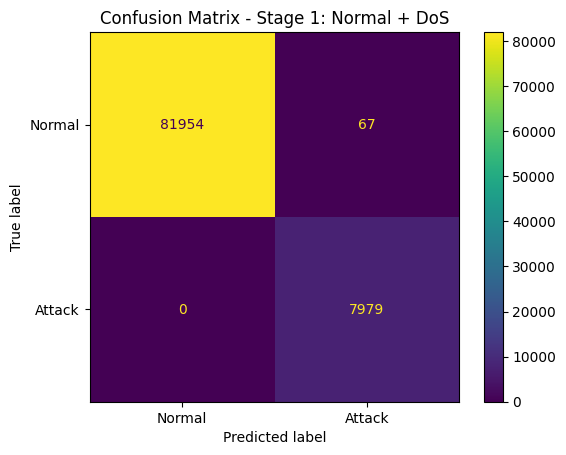


Running stage: Stage 2: Normal + DoS + RPM

Class distribution:
label
0    624607
1     75393
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    124921
           1       0.99      1.00      1.00     15079

    accuracy                           1.00    140000
   macro avg       1.00      1.00      1.00    140000
weighted avg       1.00      1.00      1.00    140000

Total prediction time: 0.036161 seconds
Average prediction time per CAN frame: 0.0000002583 seconds


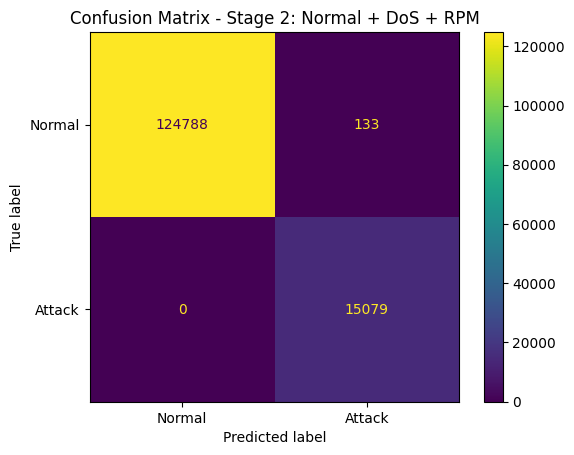


Running stage: Stage 3: Normal + DoS + RPM + Gear

Class distribution:
label
0    840917
1    109083
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    168183
           1       0.99      1.00      1.00     21817

    accuracy                           1.00    190000
   macro avg       1.00      1.00      1.00    190000
weighted avg       1.00      1.00      1.00    190000

Total prediction time: 0.037294 seconds
Average prediction time per CAN frame: 0.0000001963 seconds


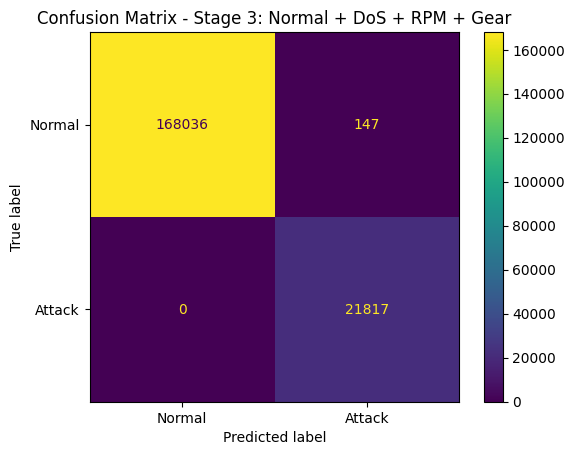


Running stage: Stage 4: Normal + DoS + Gear + RPM + Fuzzy

Class distribution:
label
0    1058917
1     141083
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97    211783
           1       0.97      0.53      0.69     28217

    accuracy                           0.94    240000
   macro avg       0.95      0.76      0.83    240000
weighted avg       0.94      0.94      0.94    240000

Total prediction time: 0.028365 seconds
Average prediction time per CAN frame: 0.0000001182 seconds


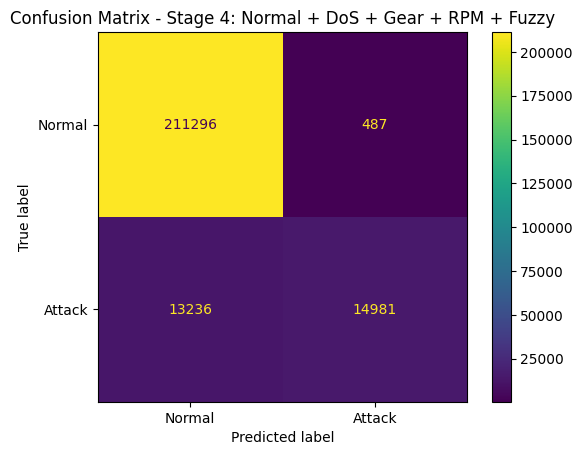

In [ ]:
# Staged experiments

model_stage_1 = run_experiment(
    "Stage 1: Normal + DoS",
    [normal_df, dos_df]
)

model_stage_2 = run_experiment(
    "Stage 2: Normal + DoS + RPM",
    [normal_df, dos_df, rpm_df]
)

model_stage_3 = run_experiment(
    "Stage 3: Normal + DoS + RPM + Gear",
    [normal_df, dos_df, rpm_df, gear_df]
)

model_stage_4 = run_experiment(
    "Stage 4: Normal + DoS + Gear + RPM + Fuzzy",
    [normal_df, dos_df, rpm_df, gear_df, fuzzy_df]
)



In [ ]:
# Results table

results_df = pd.DataFrame(results)
results_df

,stage,accuracy,precision,recall,f1_score,total_prediction_time,avg_prediction_time,test_size
0,Stage 1: Normal + DoS,0.999256,0.991673,1.000000,0.995819,0.012248,1.360844e-07,90000
1,Stage 2: Normal + DoS + RPM,0.999050,0.991257,1.000000,0.995609,0.036161,2.582925e-07,140000
2,Stage 3: Normal + DoS + RPM + Gear,0.999226,0.993307,1.000000,0.996642,0.037294,1.962858e-07,190000
3,Stage 4: Normal + DoS + Gear + RPM + Fuzzy,0.942821,0.968516,0.530921,0.685865,0.028365,1.181883e-07,240000


* Runs experiments in incremental stages  
* Stage 1 → Normal + DoS  
* Stage 2 → Adds Fuzzy attack  
* Stage 3 → Adds RPM spoofing  
* Stage 4 → Adds Gear spoofing  
* compares performance vs complexity  
* Supports evaluation of scalability and latency impact  

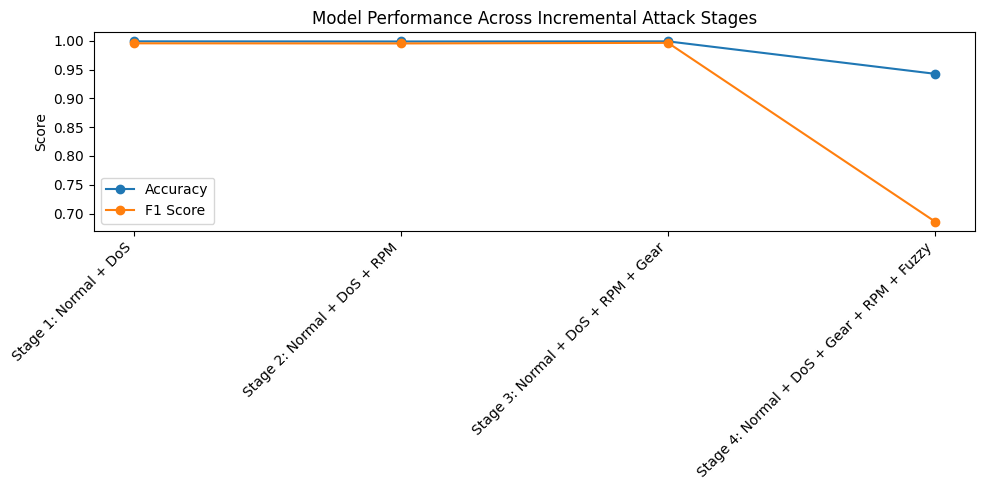

In [ ]:
#Accuracy and F1 graph

plt.figure(figsize=(10, 5))
plt.plot(results_df["stage"], results_df["accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["stage"], results_df["f1_score"], marker="o", label="F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Model Performance Across Incremental Attack Stages")
plt.legend()
plt.tight_layout()
plt.show()

* Converts experiment results into a structured DataFrame  

* Displays performance metrics for each stage  

* Includes:

  - Accuracy

  - Precision

  - Recall

  - F1 score

  - Latency  

* Enables easy comparison between stages  